In [1]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cuda:0


# **VGG19**

Files already downloaded and verified
Files already downloaded and verified

Report for epoch: 1
valid accuracy: 55.6200, valid loss: 44.3800
train accuracy: 56.8933, train loss: 43.1067


Report for epoch: 2
valid accuracy: 60.0000, valid loss: 40.0000
train accuracy: 61.8400, train loss: 38.1600


Report for epoch: 3
valid accuracy: 61.1800, valid loss: 38.8200
train accuracy: 63.8533, train loss: 36.1467


Report for epoch: 4
valid accuracy: 62.6800, valid loss: 37.3200
train accuracy: 65.9511, train loss: 34.0489


Report for epoch: 5
valid accuracy: 62.5200, valid loss: 37.4800
train accuracy: 66.6533, train loss: 33.3467


Report for epoch: 6
valid accuracy: 62.1600, valid loss: 37.8400
train accuracy: 67.5378, train loss: 32.4622


(Training finished in 6 epochs)
Average epoch's runtime: 93.67454107602437 seconds
accuracy on test data: 62.3500, loss of test data: 38.0800




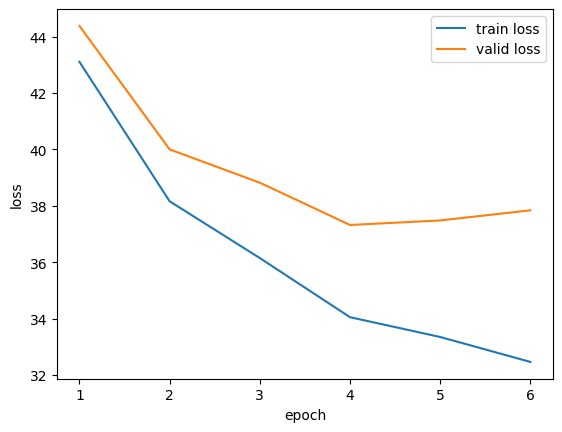

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import time
import os

model_name = 'VGG19'

# Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # نرمال سازی
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split trainset into train and validation sets
trainset, validset = random_split(trainset, [45000, 5000])

# Create data loaders
batch_size = 32
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
validloader = DataLoader(validset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

# Define VGG19 model with modifications for CIFAR-10
import torchvision.models as models

vgg19 = models.vgg19(pretrained=True)

# Freeze the pre-trained layers
for param in vgg19.features.parameters():
    param.requires_grad = False

# Modify the classifier
num_features = vgg19.classifier[6].in_features
vgg19.classifier[6] = nn.Sequential(
    nn.Linear(num_features, 1024),
    nn.ReLU(inplace=True),
    nn.Linear(1024, 512),
    nn.ReLU(inplace=True),
    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.Linear(256, 10)  # 10 classes in CIFAR-10
)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net = vgg19.to(device)

# Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)


# محاسبه دقت
def calculate_accuracy(dataloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in dataloader:
            images, labels = data
            images, labels = images.cuda(), labels.cuda()
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = round(100 * correct / total, 4)  # اعشار 4 رقمی
    return accuracy


# Training
epoch = 0
stop_condition = False

accuracy_list_valid=[]
error_list_train_plot=[]
error_list_valid_plot=[]

start_time = time.time()
while not stop_condition:
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    epoch += 1

    accuracy_valid=calculate_accuracy(validloader)
    accuracy_train=calculate_accuracy(trainloader)
    print(f'\nReport for epoch: {epoch}')
    print(f'valid accuracy: {accuracy_valid:.4f}, valid loss: {100-accuracy_valid:.4f}')
    print(f'train accuracy: {accuracy_train:.4f}, train loss: {100-accuracy_train:.4f}\n')

    error_list_valid_plot.append(100-accuracy_valid)
    error_list_train_plot.append(100-accuracy_train)
    accuracy_list_valid.append(accuracy_valid)

    #check stop condition
    last_3_acc = accuracy_list_valid[-3:]
    if max(last_3_acc) - sum(last_3_acc) / 3 <= 0.3:
        stop_condition = True
end_time = time.time()


#Report generating
avg_epoch_runtime=(end_time-start_time)/epoch

print("================================\n")
print(f"(Training finished in {epoch} epochs)")
print(f"Average epoch's runtime: {avg_epoch_runtime} seconds")
print(f'accuracy on test data: {calculate_accuracy(testloader):.4f}, loss of test data: {100-calculate_accuracy(testloader):.4f}\n\n')



if (os.path.exists('/content/drive/MyDrive/model')==False):
  os.mkdir('/content/drive/MyDrive/model')
PATH = '/content/drive/MyDrive/model/'+model_name+'.pth'
torch.save(net.state_dict(), PATH)



dataiter = iter(testloader)
images, labels = next(dataiter)



#load model
net.load_state_dict(torch.load(PATH))


#Drawing plot
import numpy as np
import matplotlib.pyplot as plt

x=list(range(1,len(error_list_train_plot)+1))

x=np.array(x)
y_train=np.array(error_list_train_plot)
y_valid=np.array(error_list_valid_plot)

plt.plot(x,y_train)
plt.plot(x,y_valid)
plt.xlabel("epoch")
plt.ylabel('loss')
plt.legend(['train loss', 'valid loss'])
plt.savefig('/content/drive/MyDrive/model/'+model_name+'.png')
plt.show()